## **Notebook PC#03 (Part A)**
## Default MLP classifier for the MNIST and CIFAR-10 databases.
**Professor:** Fernando J. Von Zuben <br>
**Cursos:** IA353A / EG453A (FEEC/Unicamp) - 1s2026 <br>
**Aluno(a):** Daniele Souza Gonçalves **RA:** 248029 <br>
**Aluno(a):** Joao Lucas Morais Ortiz **RA:** 297611 <br>

##Training an MLP for the MNIST database

In [3]:
import tensorflow as tf

mnist = tf.keras.datasets.mnist

(x_train, y_train),(x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(512, activation=tf.nn.relu),
  tf.keras.layers.Dropout(0.25),
  tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=5)
model.summary()
# Evaluate the model on the test data using `evaluate`
print("Evaluate on test data")
results = model.evaluate(x_test, y_test)
print("test loss, test acc:", results)

2026-04-19 18:52:28.688777: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-19 18:52:28.688806: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-19 18:52:28.688822: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-19 18:52:28.689160: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-19 18:52:28.689550: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/5


2026-04-19 18:52:30.188643: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1875/1875 [==============================] - 13s 5ms/step - loss: 0.4146 - accuracy: 0.8829
Epoch 2/5
1875/1875 [==============================] - 10s 5ms/step - loss: 0.4464 - accuracy: 0.8896
Epoch 3/5
1875/1875 [==============================] - 10s 5ms/step - loss: 0.5076 - accuracy: 0.8848
Epoch 4/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.5979 - accuracy: 0.8785
Epoch 5/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.6684 - accuracy: 0.8809
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (32, 784)                 0         
                                                                 
 dense (Dense)               (32, 512)                 401920    
                                                                 
 dropout (Dropout)           (32, 512)                 0         
                    

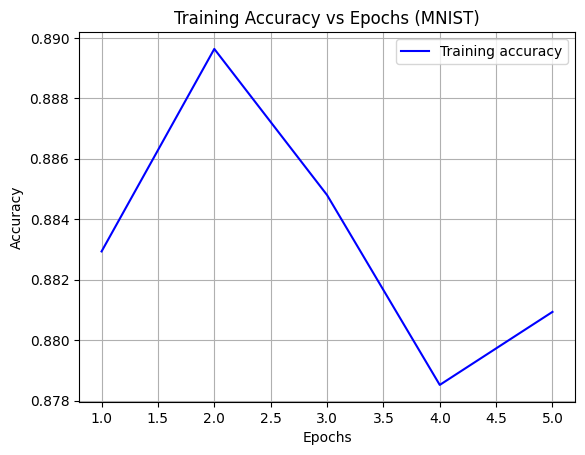

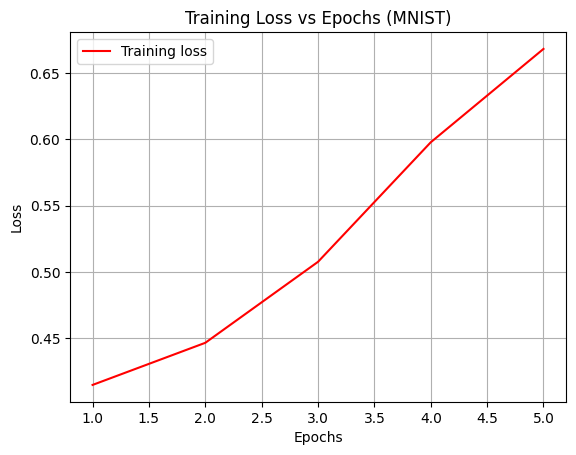

In [4]:
# Monitoring the training evolution along epochs

import matplotlib.pyplot as plt

acc = history.history['accuracy']
loss = history.history['loss']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.title('Training Accuracy vs Epochs (MNIST)')
plt.legend()
plt.grid()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.figure()
plt.plot(epochs, loss, 'r', label='Training loss')
plt.title('Training Loss vs Epochs (MNIST)')
plt.legend()
plt.grid()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [5]:
# Saving the model to disk

import os

model_json = model.to_json()
json_file = open("model_MLP_MNIST.json", "w")
json_file.write(model_json)
json_file.close()
model.save_weights("model_MLP_MNIST.weights.h5")
print("Model saved to disk")
os.getcwd()

Model saved to disk


'/Users/danielesouza/Desktop/Unicamp/IA353/notebooks_PCs01a05_IA353_1s2026 '

##Training an MLP for the CIFAR-10 database

In [6]:
cifar10 = tf.keras.datasets.cifar10

(x_train, y_train),(x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

model1 = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(1024, activation=tf.nn.relu),
  tf.keras.layers.Dropout(0.25),
  tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])
model1.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history1 = model1.fit(x_train, y_train, epochs=10)
model1.summary()
# Evaluate the model on the test data
print("Evaluate on test data")
results = model1.evaluate(x_test, y_test)
print("test loss, test acc:", results)

Epoch 1/10
1563/1563 [==============================] - 14s 8ms/step - loss: 3.0549 - accuracy: 0.2300
Epoch 2/10
1563/1563 [==============================] - 13s 8ms/step - loss: 2.8407 - accuracy: 0.2484
Epoch 3/10
1563/1563 [==============================] - 13s 8ms/step - loss: 2.8781 - accuracy: 0.2508
Epoch 4/10
1563/1563 [==============================] - 13s 8ms/step - loss: 2.8776 - accuracy: 0.2535
Epoch 5/10
1563/1563 [==============================] - 13s 8ms/step - loss: 2.9538 - accuracy: 0.2526
Epoch 6/10
1563/1563 [==============================] - 13s 8ms/step - loss: 2.9723 - accuracy: 0.2517
Epoch 7/10
1563/1563 [==============================] - 13s 8ms/step - loss: 2.9460 - accuracy: 0.2556
Epoch 8/10
1563/1563 [==============================] - 13s 9ms/step - loss: 2.9800 - accuracy: 0.2562
Epoch 9/10
1563/1563 [==============================] - 14s 9ms/step - loss: 3.0575 - accuracy: 0.2555
Epoch 10/10
1563/1563 [==============================] - 13s 9ms/step - l

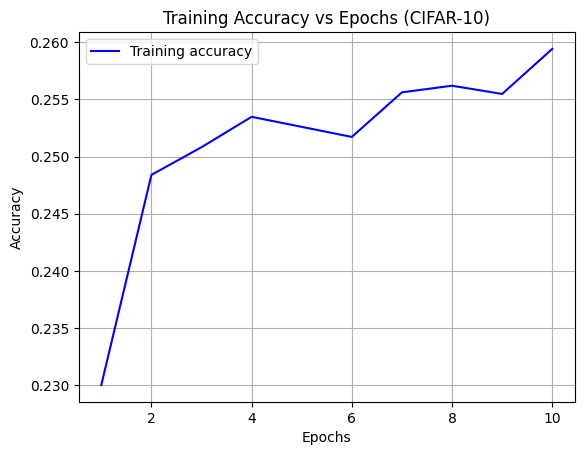

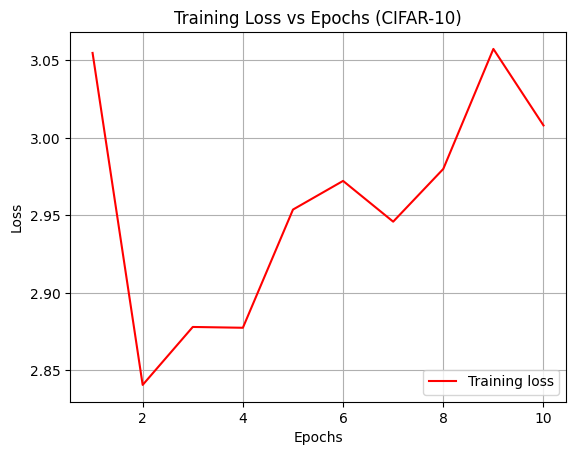

In [7]:
# Monitoring the training evolution along epochs

import matplotlib.pyplot as plt

acc = history1.history['accuracy']
loss = history1.history['loss']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.title('Training Accuracy vs Epochs (CIFAR-10)')
plt.legend()
plt.grid()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.figure()
plt.plot(epochs, loss, 'r', label='Training loss')
plt.title('Training Loss vs Epochs (CIFAR-10)')
plt.legend()
plt.grid()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [8]:
# Saving the model to disk

import os

model_json = model1.to_json()
json_file = open("model_MLP_CIFAR10.json", "w")
json_file.write(model_json)
json_file.close()
model.save_weights("model_MLP_CIFAR10.weights.h5")
print("Model saved to disk")
os.getcwd()

Model saved to disk


'/Users/danielesouza/Desktop/Unicamp/IA353/notebooks_PCs01a05_IA353_1s2026 '